In [1]:
!pip install torchreid
!pip install h5py
import torch
import torchvision
import scipy.io as io
import torchreid
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import HTML
# import all other relevant packages you need here
import cv2
import numpy as np


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.7/92.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torchreid: filename=torchreid-0.2.5-py3-none-any.whl size=144324 sha256=0cd28932191c0758b103a9afc703968da1ec0b8f5f1ae2015abd883e99514c56
  Stored in directory: /root/.cache/pip/wheels/5c/86/ff/80a1b78a90df470cbb12c075bf189ad33f1a41a881cf9e9a09
Successfully built torchreid


/usr/local/lib/python3.12/dist-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


# Sample display video code

In [2]:
!pip -q install gdown
import os
import gdown

drive_url = "https://drive.google.com/file/d/14uCH3yQLKzPFoN-ubvfJyLYNm7Imipc7/view?usp=sharing"
file_path = "video.mat"

if not os.path.exists(file_path):
    gdown.download(url=drive_url, output=file_path, fuzzy=True, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=14uCH3yQLKzPFoN-ubvfJyLYNm7Imipc7
From (redirected): https://drive.google.com/uc?id=14uCH3yQLKzPFoN-ubvfJyLYNm7Imipc7&confirm=t&uuid=e513fbb6-7d00-4e08-b0b2-6dc56d93f45c
To: /content/video.mat
100%|██████████| 349M/349M [00:06<00:00, 55.7MB/s] 


In [3]:
video_rgb = io.loadmat(file_path)["I"]

def display_video(video):
  fig = plt.figure(figsize=(5,5))
  mov = []
  for i in range(video.shape[3]):
    img = plt.imshow(video[:, :, :, i], animated=True)
    plt.axis('off')
    mov.append([img])

  movie = animation.ArtistAnimation(fig, mov, interval=20, repeat_delay=1000)
  plt.close()
  return movie

HTML(display_video(video_rgb).to_html5_video())

In [4]:
def load_video(file_path):
  # load video
  video_rgb = io.loadmat(file_path)['I'] # video loaded with shape HxWx3XT where T is the total number of frames

  video_grayscale = # convert each frame of above video to grayscale
  return video_rgb,video_grayscale

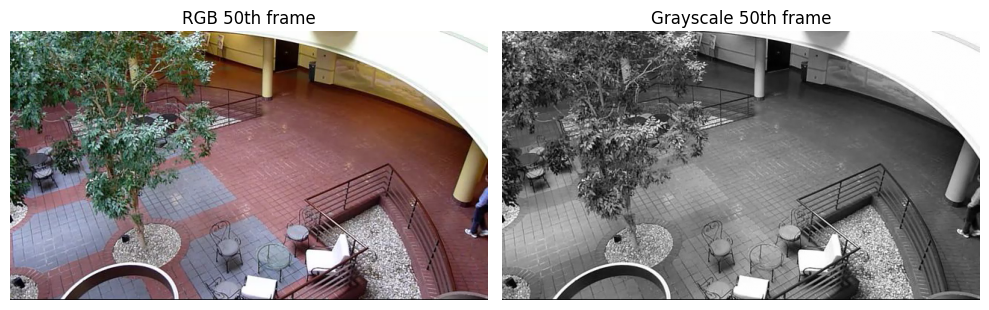

In [5]:
video_rgb, video_grayscale = load_video(file_path)

frame_idx = 49  
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(video_rgb[:, :, :, frame_idx])
plt.title("RGB 50th frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(video_grayscale[:, :, frame_idx], cmap="gray")
plt.title("Grayscale 50th frame")
plt.axis("off")

plt.tight_layout()
plt.show()

Only one person is visible in the bottom-right at frame 50

In [6]:
def getSumOfDiff(image_set):
  # image_set is a set of 3 frames of size 3XHxW with each frame being a grayscale image
  # must return a sum of difference image named sod_image
  import numpy as np
  from math import comb
  N = len(image_set)
  num_pairs = comb(N, 2)
  acc = np.zeros_like(image_set[0], dtype=np.float64)
  for i in range(N - 1):
    for j in range(i + 1, N):
      acc += np.abs(image_set[i].astype(np.float64) - image_set[j].astype(np.float64))
  sod_image = (acc / num_pairs).astype(np.uint8)
  return sod_image


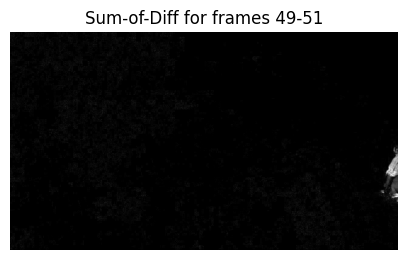

In [7]:
import numpy as np
image_set = np.transpose(video_grayscale[:, :, 48:51], (2, 0, 1))
D_sample = getSumOfDiff(image_set)

plt.figure(figsize=(5,5))
plt.imshow(D_sample, cmap="gray")
plt.title("Sum-of-Diff for frames 49-51")
plt.axis("off")
plt.show()

The SoD image is almost entirely black except a  bright blob in bottom-right corresponding to the moving person

In [8]:
def getDetections(sod_image):
  # sod_image is a sum of difference image
  # Returns a list bounding boxes of clustered motion information from sod_image
  sod = sod_image.copy()
  _, mask = cv2.threshold(sod, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
  kernel = np.ones((5, 5), np.uint8)
  mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
  bounding_boxes = []
  min_area = 80 
  for i in range(1, num_labels):  
      x, y, w, h, area = stats[i]
      if area >= min_area:
          bounding_boxes.append([int(x), int(y), int(w), int(h)])
  return np.array(bounding_boxes, dtype=np.int32)

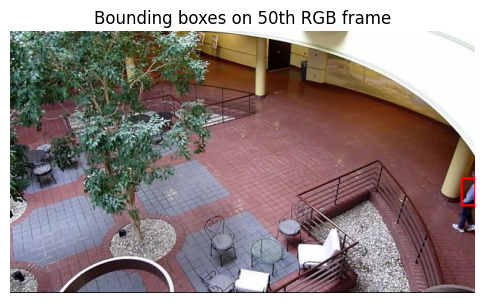

In [9]:
import cv2
frame_idx = 49  
frame_rgb = video_rgb[:, :, :, frame_idx].copy()
boxes = getDetections(D_sample)

vis = frame_rgb.copy()
for (x, y, w, h) in boxes:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(vis)
plt.title("Bounding boxes on 50th RGB frame")
plt.axis("off")
plt.show()

A bounding box was detected around only the moving person (recall is 1 and precision is 1 as well) although not around thw whole person

In [10]:
def getDeepFeatures(image, bbox, model):
  device = torch.device('cuda:0') if torch.cuda.is_available() else 'cpu'
  model = model.to(device)
  model.eval()

  transform = torchvision.transforms.Compose([
    torchvision.transforms.ToPILImage(),
    torchvision.transforms.Resize((224, 224)),  
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
  ])

  if bbox is None or len(bbox) == 0:
    return np.zeros((0, 2048), dtype=np.float32)

  H, W = image.shape[:2]
  feat = np.zeros((len(bbox), 2048), dtype=np.float32)

  with torch.no_grad():
    for i, box in enumerate(bbox):
      x, y, w, h = [int(v) for v in box]
      x1, y1 = max(0, x), max(0, y)
      x2, y2 = min(W, x + w), min(H, y + h)

      if x1 >= x2 or y1 >= y2:
        continue

      patch = image[y1:y2, x1:x2, :]           
      patch_t = transform(patch).unsqueeze(0).to(device)

      features = model(patch_t)
      features = features.view(features.size(0), -1)[0].cpu().numpy().astype(np.float32)
      feat[i, :] = features[:2048]

  return feat   


In [11]:
def getMatches(feat1,feat2):
  # feat1 and feat2 are two feature matrices of dimensions N1 x n_feat and N2 x n_feat respectively
  # where N1 = no of bboxes in frame1 and N2 = no of bboxes in frame2
  # returns matches a N x 2 matrix indicating the indices of matched bboxes. N <= min(N1,N2)

  # YOUR CODE HERE. DO NOT CHANGE ANYTHING ABOVE THIS.
  if feat1 is None or feat2 is None or feat1.shape[0] == 0 or feat2.shape[0] == 0:
    return np.zeros((0, 2), dtype=np.int32)

  a2 = np.sum(feat1**2, axis=1, keepdims=True)
  b2 = np.sum(feat2**2, axis=1, keepdims=True).T
  dist = a2 + b2 - 2 * (feat1 @ feat2.T)
  dist = np.clip(dist, 0, np.inf)

  j_best = np.argmin(dist, axis=1)
  i_best = np.argmin(dist, axis=0)

  matches = []
  for i, j in enumerate(j_best):
    if i_best[j] == i:
      matches.append([i, j])

  if len(matches) == 0:
    return np.zeros((0, 2), dtype=np.int32)

  return np.array(matches, dtype=np.int32)

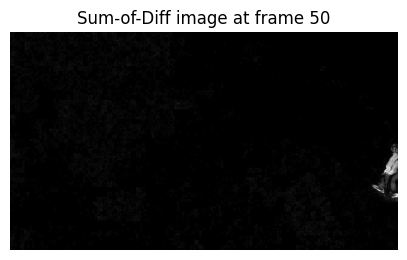

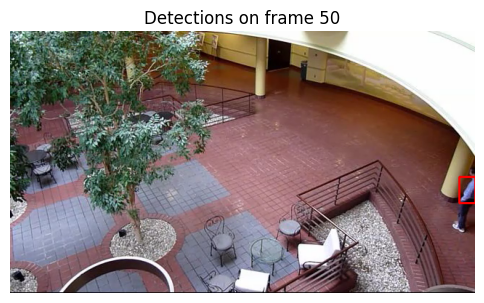

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 280MB/s]


In [12]:
import numpy as np
import cv2

# load video
file_path = "video.mat" # path to video.mat
video_rgb, video_grayscale = load_video(file_path)

# get sample sum-of-difference image centered at frame `offset`
offset = 50
D1 = getSumOfDiff(np.transpose(video_grayscale[:, :, offset-1:offset+2], (2, 0, 1)))

plt.figure(figsize=(5, 5))
plt.imshow(D1, cmap="gray")
plt.title(f"Sum-of-Diff image at frame {offset}")
plt.axis("off")
plt.show()

bbox1 = getDetections(D1)

vis = video_rgb[:, :, :, offset].copy()
for (x, y, w, h) in bbox1:
    cv2.rectangle(vis, (int(x), int(y)), (int(x + w), int(y + h)), (255, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(vis)
plt.title(f"Detections on frame {offset}")
plt.axis("off")
plt.show()

detections = []
detections.append((offset, bbox1))
matchings = []

model = torchreid.models.build_model(
    name="resnet50",
    num_classes=10,
    loss="softmax",
    pretrained=True
)

if hasattr(model, "classifier"):
    model.classifier = torch.nn.Identity()
extractor = model

feat1 = getDeepFeatures(video_rgb[:, :, :, offset], bbox1, extractor)

for i in range(offset, video_rgb.shape[3] - 2):
    # build SoD for next frame (i+1): frames i, i+1, i+2
    D2 = getSumOfDiff(np.transpose(video_grayscale[:, :, i:i+3], (2, 0, 1)))
    bbox2 = getDetections(D2)

    if len(bbox2) == 0:
        continue

    detections.append((i + 1, bbox2))
    feat2 = getDeepFeatures(video_rgb[:, :, :, i + 1], bbox2, extractor)

    M = getMatches(feat1, feat2)
    if len(M) == 0:
        continue

    matchings.append((i, i + 1, M))

    D1 = D2
    bbox1 = bbox2
    feat1 = feat2

fig = plt.figure(figsize=(6, 6))
det_mov = []
for f_idx, boxes in detections:
    frame = video_rgb[:, :, :, f_idx].copy()
    for (x, y, w, h) in boxes:
        cv2.rectangle(frame, (int(x), int(y)), (int(x + w), int(y + h)), (255, 0, 0), 2)
    img = plt.imshow(frame, animated=True)
    plt.axis("off")
    det_mov.append([img])

det_video = animation.ArtistAnimation(fig, det_mov, interval=50, repeat_delay=1000)
plt.close(fig)
HTML(det_video.to_html5_video())

fig = plt.figure(figsize=(10, 5))
match_mov = []

def _centroid(box):
    x, y, w, h = box
    return np.array([x + w / 2.0, y + h / 2.0])

for t, t1, M in matchings:
    box_t = None
    box_t1 = None
    for f_idx, boxes in detections:
        if f_idx == t:
            box_t = boxes
        elif f_idx == t1:
            box_t1 = boxes
    if box_t is None or box_t1 is None:
        continue

    left = video_rgb[:, :, :, t]
    right = video_rgb[:, :, :, t1]
    canvas = np.concatenate([left, right], axis=1)
    w_left = left.shape[1]

    artists = []
    im = plt.imshow(canvas, animated=True)
    artists.append(im)
    plt.axis("off")

    for i_idx, j_idx in M:
        if i_idx >= len(box_t) or j_idx >= len(box_t1):
            continue
        c1 = _centroid(box_t[int(i_idx)])
        c2 = _centroid(box_t1[int(j_idx)]) + np.array([w_left, 0])
        ln, = plt.plot([c1[0], c2[0]], [c1[1], c2[1]], "y-", linewidth=1.5, animated=True)
        p1, = plt.plot(c1[0], c1[1], "ro", markersize=3, animated=True)
        p2, = plt.plot(c2[0], c2[1], "go", markersize=3, animated=True)
        artists.extend([ln, p1, p2])

    match_mov.append(artists)

match_video = animation.ArtistAnimation(fig, match_mov, interval=120, repeat_delay=1000)
plt.close(fig)
HTML(match_video.to_html5_video())

The bounding boxes are able to consistently follow the moving person..